In [1]:
# Permet de recharger automatiquement les modules si tu modifies le code dans src
%load_ext autoreload
%autoreload 2

import sys
import os

# Ajoute le dossier racine du projet au chemin de recherche de Python
sys.path.append(os.path.abspath(os.path.join('..')))

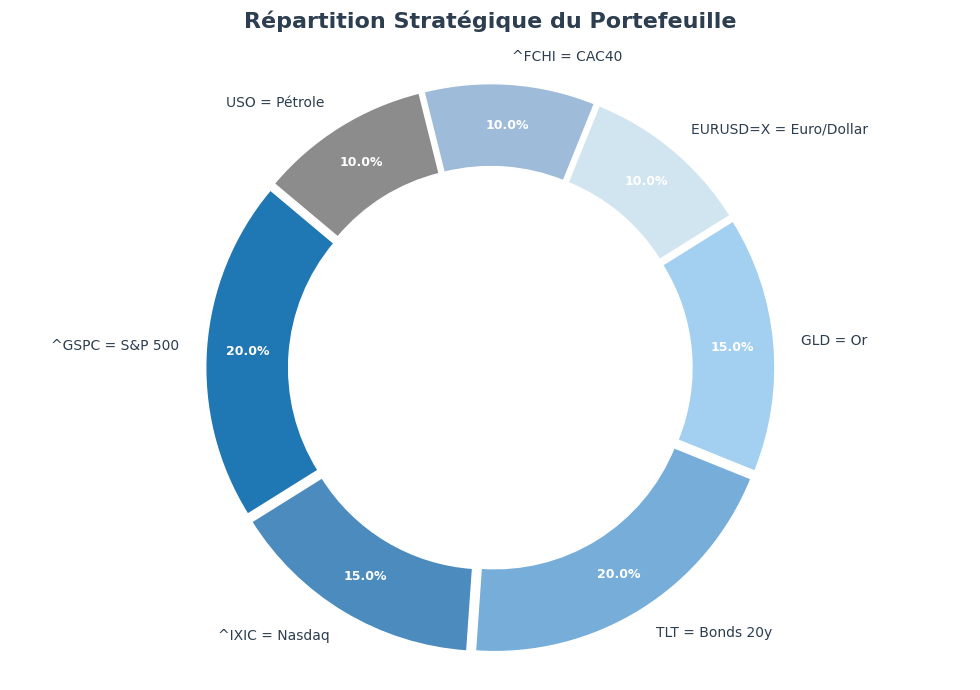

In [ ]:
import matplotlib.pyplot as plt

# 1. Configuration des données
tickers = [
    '^GSPC = S&P 500', 
    '^IXIC = Nasdaq', 
    'TLT = Bonds 20y', 
    'GLD = Or', 
    'EURUSD=X = Euro/Dollar', 
    '^FCHI = CAC40', 
    'USO = Pétrole' 
]
weights = [20, 15, 20, 15, 10, 10, 10]

# 2. Palette de couleurs
colors = ['#1f77b4', '#4b8bbe', '#77add9', '#a3cff0', '#d1e5f0', '#9ebcda', '#8c8c8c']

# 3. Création du graphique
# On initialise la figure.
fig, ax = plt.subplots(figsize=(10, 7), dpi=100)

# Pour s'assurer que le fond de la figure est bien considéré comme transparent dans l'objet Python
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

# Dessin du graphique en secteurs (Pie Chart) avec transformation en Donut native
wedges, texts, autotexts = ax.pie(
    weights, 
    labels=tickers, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors, 
    pctdistance=0.85, 
    explode=[0.03]*7,
    textprops={'fontsize': 10, 'color': '#2c3e50'},
    # C'est ici que la magie opère pour la transparence du centre :
    # width=0.3 signifie que l'anneau fait 30% du rayon, laissant un trou de 70% (comme votre cercle 0.70)
    wedgeprops={'width': 0.3, 'edgecolor': 'white'} 
)

# NOTE : J'ai supprimé l'étape "centre_circle" car wedgeprops gère le trou 
# tout en le gardant transparent.

# 4. Stylisation des pourcentages
plt.setp(autotexts, size=9, weight="bold", color="white")

# 5. Titre et mise en forme finale
ax.set_title("Répartition Stratégique du Portefeuille", fontsize=16, fontweight='bold', pad=20, color='#2c3e50')
ax.axis('equal') 

plt.tight_layout()

# 6. Sauvegarde avec fond transparent (IMPORTANT)
# C'est cette commande qui crée le fichier image final transparent
# plt.savefig('portefeuille_transparent.png', transparent=True, dpi=300)

plt.show()

In [2]:
# Maintenant on peut importer nos propres classes
from src.data_loader import DataLoader

tickers = ['^GSPC', '^IXIC', '^FCHI', 'GLD', 'USO', 'TLT', 'BTC-USD', 'EURUSD=X']
data_loader = DataLoader(tickers, start='2010-01-01', end='2023-12-31')

data = data_loader.load_data()

data.head(5)

c:\Users\anton\Documents\ENSAI\GDR\Projet strat invest direc\src\data_loader.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(self.tickers, period=self.period, start=self.start, end=self.end, interval='1wk')
[*********************100%***********************]  8 of 8 completed
c:\Users\anton\Documents\ENSAI\GDR\Projet strat invest direc\src\data_loader.py:21: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stock_data = stock_data.ffill().dropna().stack()


Price                     Close        High         Low        Open  \
Date       Ticker                                                     
2014-09-15 BTC-USD   398.821014  468.174011  384.532013  465.864014   
           EURUSD=X    1.285000    1.298094    1.285017    1.292474   
           GLD       117.779999  119.430000  117.190002  118.629997   
           TLT        83.441780   84.112792   83.124707   83.832590   
           USO       276.959991  283.359985  273.519989  276.720001   

Price                     Volume  
Date       Ticker                 
2014-09-15 BTC-USD   156903400.0  
           EURUSD=X          0.0  
           GLD        33143800.0  
           TLT        45878500.0  
           USO         2744551.0

In [3]:
from src.features import FeatureEngineer

# On suppose que 'df_final' est ton DataFrame propre issu du DataLoader
fe = FeatureEngineer(data)

# Ajout des indicateurs
fe.add_moving_average(window=50, title='SMA_50')
fe.add_moving_average(window=200, title='SMA_200')
fe.add_rsi(window=14)

# Vérification visuelle
print(fe.data.tail(10)) # Regarde la fin pour voir les calculs

Price                       Close          High           Low          Open  \
Date       Ticker                                                             
2023-12-25 ^GSPC      4783.350098   4793.299805   4736.770020   4753.919922   
           ^IXIC     15095.139648  15150.070312  14927.120117  15006.179688   
2023-12-29 BTC-USD   42265.187500  43804.781250  41424.062500  43010.574219   
           EURUSD=X      1.105583      1.108647      1.104326      1.106819   
           GLD         191.169998    191.639999    190.740005    190.990005   
           TLT          90.931763     91.796205     90.858199     91.161667   
           USO          66.650002     67.750000     66.629997     67.680000   
           ^FCHI      7543.180176   7603.270020   7530.930176   7580.970215   
           ^GSPC      4769.830078   4788.430176   4751.990234   4782.879883   
           ^IXIC     15011.349609  15111.410156  14955.370117  15099.200195   

Price                      Volume        SMA_50    

In [4]:
from src.strategy import Strategy

strat = Strategy(fe.data)
data_full = strat.define_market_regime()
data_full.tail(10)

Price                       Close          High           Low          Open  \
Date       Ticker                                                             
2023-12-25 ^GSPC      4783.350098   4793.299805   4736.770020   4753.919922   
           ^IXIC     15095.139648  15150.070312  14927.120117  15006.179688   
2023-12-29 BTC-USD   42265.187500  43804.781250  41424.062500  43010.574219   
           EURUSD=X      1.105583      1.108647      1.104326      1.106819   
           GLD         191.169998    191.639999    190.740005    190.990005   
           TLT          90.931763     91.796205     90.858199     91.161667   
           USO          66.650002     67.750000     66.629997     67.680000   
           ^FCHI      7543.180176   7603.270020   7530.930176   7580.970215   
           ^GSPC      4769.830078   4788.430176   4751.990234   4782.879883   
           ^IXIC     15011.349609  15111.410156  14955.370117  15099.200195   

Price                      Volume        SMA_50       SMA_200        RSI  \
Date       Ticker                                                          
2023-12-25 ^GSPC     1.100799e+10   4461.974824   4175.238416  90.886860   
           ^IXIC     2.348794e+10  13840.940000  12522.024434  89.432104   
2023-12-29 BTC-USD   1.578071e+11  32391.612187  27948.566582  67.978030   
           EURUSD=X  0.000000e+00      1.082226      1.065540  67.947097   
           GLD       4.612300e+06    181.444399    174.607850  81.175553   
           TLT       4.161620e+07     84.519958     94.535020  79.363470   
           USO       3.305500e+06     73.075200     71.479000  36.061555   
           ^FCHI     9.067260e+07   7257.805176   6831.924199  74.732015   
           ^GSPC     3.126060e+09   4467.170625   4176.700366  84.387159   
           ^IXIC     5.441060e+09  13858.395586  12527.687080  79.915973   

Price                Regime  
Date       Ticker            
2023-12-25 ^GSPC          1  
           ^IXIC          1  
2023-12-29 BTC-USD        1  
           EURUSD=X       1  
           GLD            1  
           TLT            0  
           USO            0  
           ^FCHI          1  
           ^GSPC          1  
           ^IXIC          1

In [5]:
summary = strat.get_signal_summary()
print(summary)

Regime     -1    0    1
Ticker                 
BTC-USD   103  519  348
EURUSD=X  282  517  171
GLD        51  553  366
TLT       247  553  170
USO       184  610  176
^FCHI      50  565  355
^GSPC      30  428  512
^IXIC      54  390  526


--- ANALYSE FOCUS SUR GLD ---


c:\Users\anton\Documents\ENSAI\GDR\Projet strat invest direc\src\data_loader.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(self.tickers, period=self.period, start=self.start, end=self.end, interval='1wk')
[*********************100%***********************]  1 of 1 completed
c:\Users\anton\Documents\ENSAI\GDR\Projet strat invest direc\src\data_loader.py:21: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stock_data = stock_data.ffill().dropna().stack()


Application FracDiff (d=0.3, fenêtre=387)...
Train : 509 semaines | Test : 128 semaines

--- Fit ARIMA ---
--- Fit ARIMA (Mode Numérique) ---
Ordre ARIMA trouvé : (0, 0, 0)

--- Fit XGBoost ---
--- Entraînement XGBoost (MSE) ---

--- Résultats ---
RMSE Prix : 6.71
Précision Directionnelle : 55.47%


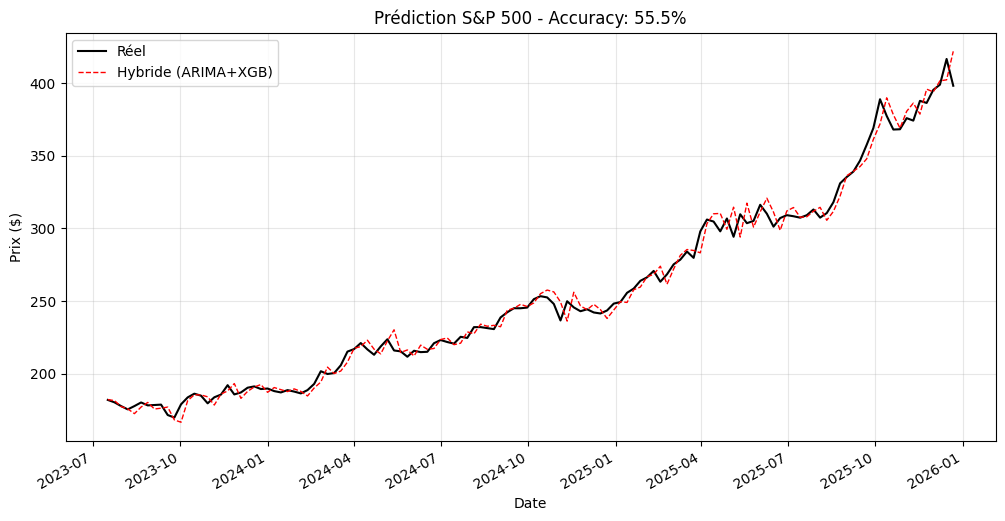


Top Features (Ce qui corrige ARIMA) :
     Feature  Importance
5  Ret_Lag_5    0.106886
3  Ret_Lag_2    0.146718
2  Ret_Lag_1    0.151356
4  Ret_Lag_3    0.156532
1        RSI    0.278054


In [8]:
# ==============================================================================
# PIPELINE DE RÉPARATION - HYBRIDE SINGLE ASSET
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_squared_error, accuracy_score
from src.data_loader import DataLoader
from src.features import FeatureEngineer
from src.models import ModelPreparator, StatisticalModeler, XGBoostModeler, ASSETS_CONFIG

# --- 1. CONFIGURATION ---
TARGET_TICKER = 'GLD'  # Or
TRAIN_SPLIT = 0.80

print(f"--- ANALYSE FOCUS SUR {TARGET_TICKER} ---")

# --- 2. CHARGEMENT SINGLE ASSET ---
# On ne charge QUE l'actif cible pour éviter la pollution du Cluster pour l'instant
loader = DataLoader(tickers=[TARGET_TICKER], period="20y")
raw_data = loader.load_data()

# --- 3. FEATURE ENGINEERING ---
fe = FeatureEngineer(raw_data)
# Indicateurs techniques
df_feat = fe.add_moving_average(window=20, title='SMA_20')
df_feat = fe.add_rsi(window=14)
# Lags (Mémoire court terme)
df_feat = fe.add_lags(lags=[1, 2, 3, 5])

# --- 4. PRÉPARATION & FRACDIFF ---
prep = ModelPreparator(df_feat)
prep.prepare_data()

# Scaling manuel global pour consistance (Tout en %)
# On multiplie les Log Returns par 100 tout de suite
prep.data['Log Returns'] = prep.data['Log Returns'] * 100.0
prep.data['Target'] = prep.data['Target'] * 100.0
# Les Lags doivent aussi être mis à jour (car calculés avant le x100)
for col in [c for c in prep.data.columns if 'Ret_Lag' in c]:
    prep.data[col] = prep.data[col] * 100.0

# FracDiff (Mémoire long terme)
# On utilise d=0.3 qui est un bon compromis stationnaire/mémoire
prep.frac_diff_ffd(d=0.3, thres=1e-4)

# --- 5. SPLIT TEMPOREL PROPRE ---
# On utilise la méthode simple (pas de cluster)
train_df, test_df = prep.train_test_split(train_size=TRAIN_SPLIT)

print(f"Train : {len(train_df)} semaines | Test : {len(test_df)} semaines")

# --- 6. ARIMA (TENDANCE) ---
print("\n--- Fit ARIMA ---")
# On entraîne UNIQUEMENT sur la série temporelle du Train
y_train_series = train_df['Log Returns'].dropna() # Déjà en %

# Note: On utilise StatisticalModeler juste pour ARIMA ici
# On triche un peu : on passe une série qui est déjà *100, 
# donc StatisticalModeler va la re-multiplier par 100 (x10000).
# Pour éviter ça, on divise par 100 avant de lui passer.
stat_modeler = StatisticalModeler(y_train_series / 100.0) 
arima_model = stat_modeler.fit_arima()

# Prédiction ARIMA sur le Test (Base Line)
arima_pred_test = arima_model.predict(n_periods=len(test_df))
# Remise en format Series alignée
if not isinstance(arima_pred_test, pd.Series):
    arima_pred_test = pd.Series(arima_pred_test, index=test_df.index)

# Calcul des Résidus sur le Train (Ce que XGBoost doit apprendre)
# Attention aux index ! ARIMA.resid() retourne un array
# Il faut l'aligner avec y_train_series
resid_train_values = stat_modeler.residuals
# Sécurité taille
min_len = min(len(y_train_series), len(resid_train_values))
resid_train = pd.Series(resid_train_values[-min_len:], index=y_train_series.index[-min_len:])

# --- 7. XGBOOST (CORRECTION) ---
print("\n--- Fit XGBoost ---")

# Préparation X, y
# On utilise get_X_y mais on va remplacer le y par les résidus !
X_train_full, _, X_test, _, scaler = prep.get_X_y(train_df, test_df)

# ALIGNEMENT CRITIQUE X vs Résidus
# ARIMA (d=1) perd souvent la première valeur. FracDiff en perd plusieurs.
# On trouve l'intersection des index
common_index_train = train_df.index.intersection(resid_train.index)
# On filtre X_train pour ne garder que les lignes où on a un résidu
# Il faut retrouver les indices numériques correspondants dans X_train_full (numpy array)
# Astuce : on refait le split indices proprement
mask_train = train_df.index.isin(common_index_train)
X_train_aligned = X_train_full[mask_train] # Attention, X_train_full est un numpy array, il faut un masque booléen de la bonne taille
# Correction plus simple : on refait get_X_y sur le subset
train_subset = train_df.loc[common_index_train]
X_train_aligned, _, _, _, _ = prep.get_X_y(train_subset, test_df)

y_train_xgb = resid_train.loc[common_index_train]

# Entraînement
xgb_modeler = XGBoostModeler(n_estimators=200, max_depth=3, learning_rate=0.05)
xgb_modeler.train(X_train_aligned, y_train_xgb, use_custom_loss=False) # MSE pour stabiliser

# Prédiction Résidus
xgb_pred_resid = xgb_modeler.predict(X_test)
xgb_pred_resid = pd.Series(xgb_pred_resid, index=test_df.index)

# --- 8. RÉSULTATS (CORRIGÉS) ---
print("\n--- Résultats ---")

# A. Calcul des prédictions finales (Décimales)
final_pred_pct = arima_pred_test + xgb_pred_resid
final_pred_decimal = final_pred_pct / 100.0  # On repasse en décimales (ex: 0.01)

# B. CORRECTION DU PRIX RÉEL
# Important : prep.data['Target'] est actuellement x100 (ex: 1.5).
# La fonction reconstruct_prices l'utilise telle quelle, ce qui fait exploser le prix réel.
# On divise temporairement par 100 pour que le calcul P * exp(r) soit juste.
prep.data['Target'] = prep.data['Target'] / 100.0

# Reconstruction
results = prep.reconstruct_prices(predictions=final_pred_decimal, index=test_df.index)
results = results.dropna()

# On remet l'échelle x100 au cas où on relance la cellule (pour ne pas diviser 2 fois)
prep.data['Target'] = prep.data['Target'] * 100.0

# C. Métriques
rmse = np.sqrt(mean_squared_error(results['Actual_Close_t+1'], results['Predicted_Close_t+1']))

# Directional Accuracy
# On compare les signes des rendements (peu importe l'échelle, le signe reste le même)
# target_decimal est recalculé proprement depuis les prix reconstruits pour être sûr
target_returns = np.log(results['Actual_Close_t+1'] / results['Close_t'])
acc = np.mean(np.sign(final_pred_decimal.loc[results.index]) == np.sign(target_returns))

print(f"RMSE Prix : {rmse:.2f}")
print(f"Précision Directionnelle : {acc*100:.2f}%")

# --- GRAPHIQUE ---
import matplotlib.dates as mdates

plt.figure(figsize=(12, 6))

# Extraction propre des dates
plot_dates = results.index.get_level_values('Date')

plt.plot(plot_dates, results['Actual_Close_t+1'], label='Réel', color='black', linewidth=1.5)
plt.plot(plot_dates, results['Predicted_Close_t+1'], label='Hybride (ARIMA+XGB)', color='red', linestyle='--', linewidth=1)

plt.title(f"Prédiction S&P 500 - Accuracy: {acc*100:.1f}%")
plt.xlabel("Date")
plt.ylabel("Prix ($)")
plt.legend()
plt.grid(True, alpha=0.3)

# Formatage Date
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gcf().autofmt_xdate()

plt.show()

# Importance des features
feats = prep.get_feature_names(train_subset)
imp = xgb_modeler.get_feature_importance(feats)
print("\nTop Features (Ce qui corrige ARIMA) :")
print(imp.tail(5))

In [6]:
from src.models import ModelPreparator
from src.models import RegressionModels
import pandas as pd

print("\n--- 3. Préparation des données pour la Régression ---")
preparator = ModelPreparator(data_full)

# Calcul des rendements et de la Target (J+1)
df_prepped = preparator.prepare_data()

# Split Chronologique (Train sur le passé, Test sur le futur récent)
train_df, test_df = preparator.train_test_split(train_size=0.8)

# Séparation X/y, nettoyage et standardisation
# Note: cela retire automatiquement les colonnes non-predictives (Prix, Date, etc.)
X_train, y_train, X_test, y_test, scaler = preparator.get_X_y(train_df, test_df)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape : {X_test.shape},  y_test shape : {y_test.shape}")

# =============================================================================
# 5. ENTRAÎNEMENT ET ÉVALUATION
# =============================================================================
print("\n--- 4. Entraînement et Résultats ---")
models = RegressionModels()

# A) Modèle Linéaire (Benchmark)
print("\n[Modèle Linéaire - Ridge]")
model_linear = models.train_linear(X_train, y_train)
res_linear = models.evaluate(model_linear, X_test, y_test)

# B) Random Forest
print("\n[Modèle Random Forest]")
model_rf = models.train_random_forest(X_train, y_train)
res_rf = models.evaluate(model_rf, X_test, y_test)

# =============================================================================
# 6. EXEMPLE DE PRÉDICTION
# =============================================================================
print("\n--- 5. Exemple de prédiction sur les 5 dernières semaines ---")
# On regarde les vraies valeurs vs prédictions du Random Forest
comparison = pd.DataFrame({
    'Vrai Rendement': y_test,
    'Prédiction RF': res_rf['Predictions'],
    'Prédiction Linéaire': res_linear['Predictions']
})
print(comparison)


--- 3. Préparation des données pour la Régression ---
X_train shape: (4928, 6), y_train shape: (4928,)
X_test shape : (1232, 6),  y_test shape : (1232,)

--- 4. Entraînement et Résultats ---

[Modèle Linéaire - Ridge]
Entraînement Modèle Linéaire (Ridge)...

[Modèle Random Forest]
Entraînement Random Forest...

--- 5. Exemple de prédiction sur les 5 dernières semaines ---
                     Vrai Rendement  Prédiction RF  Prédiction Linéaire
Date       Ticker                                                      
2022-07-08 BTC-USD        -0.003896      -0.044547            -0.007351
           EURUSD=X        0.000000       0.000667            -0.001212
           GLD             0.000000       0.000571            -0.001541
           TLT             0.000000       0.000520             0.000942
           USO             0.000000       0.000730            -0.000034
...                             ...            ...                  ...
2023-12-25 TLT            -0.009061       0.0002

--- Métriques Directionnelles ---
Directional Accuracy: 25.65%

Matrice de Confusion (Lignes=Vrai, Colonnes=Prédit):
             Pred Hausse  Pred Baisse
Vrai Hausse          263           68
Vrai Baisse          232           53


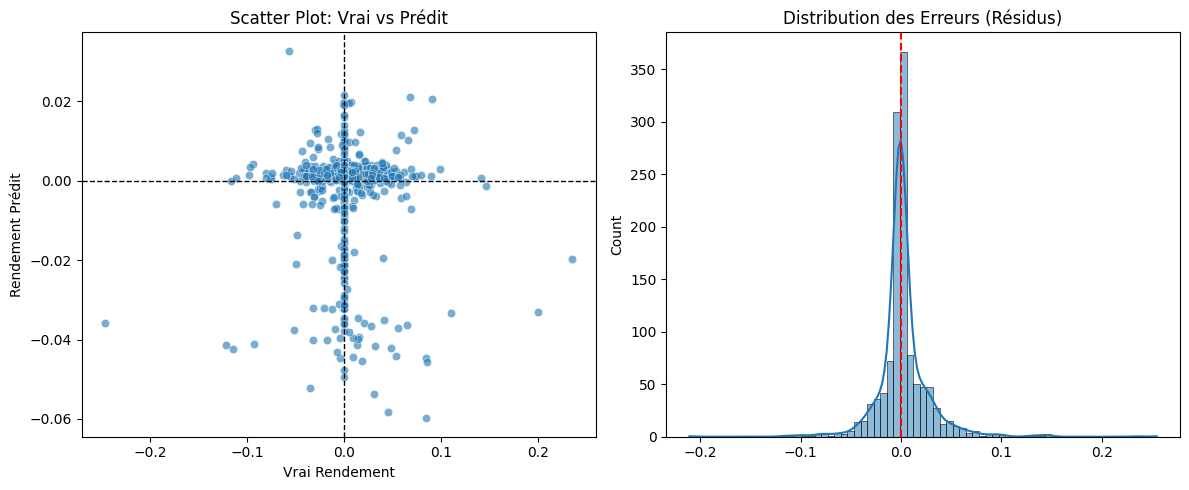

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np

def analyze_predictions(comparison_df):
    """
    Analyse approfondie des prédictions directionnelles.
    """
    df = comparison_df.copy()
    
    # 1. Calcul du signe (1 si positif, -1 si négatif)
    # On utilise une petite tolérance pour éviter les zéros parfaits
    df['Sign_True'] = np.sign(df['Vrai Rendement'])
    df['Sign_Pred'] = np.sign(df['Prédiction RF'])
    
    # 2. Métrique : Précision Directionnelle (Accuracy)
    accuracy = accuracy_score(df['Sign_True'], df['Sign_Pred'])
    print(f"--- Métriques Directionnelles ---")
    print(f"Directional Accuracy: {accuracy:.2%}")
    
    # 3. Matrice de Confusion (Quand on se trompe, est-ce grave ?)
    # True Positive: On prédit Hausse, c'est Hausse
    # False Positive: On prédit Hausse, c'est Baisse (Danger !)
    cm = confusion_matrix(df['Sign_True'], df['Sign_Pred'], labels=[1, -1])
    
    print("\nMatrice de Confusion (Lignes=Vrai, Colonnes=Prédit):")
    print(pd.DataFrame(cm, index=['Vrai Hausse', 'Vrai Baisse'], columns=['Pred Hausse', 'Pred Baisse']))
    
    # 4. Visualisation Graphique
    plt.figure(figsize=(12, 5))
    
    # Scatter Plot : Prédit vs Réel
    plt.subplot(1, 2, 1)
    sns.scatterplot(x='Vrai Rendement', y='Prédiction RF', data=df, alpha=0.6)
    plt.axhline(0, color='black', linestyle='--', lw=1)
    plt.axvline(0, color='black', linestyle='--', lw=1)
    plt.title("Scatter Plot: Vrai vs Prédit")
    plt.xlabel("Vrai Rendement")
    plt.ylabel("Rendement Prédit")
    
    # Histogramme des erreurs
    plt.subplot(1, 2, 2)
    errors = df['Vrai Rendement'] - df['Prédiction RF']
    sns.histplot(errors, kde=True)
    plt.title("Distribution des Erreurs (Résidus)")
    plt.axvline(0, color='r', linestyle='--')
    
    plt.tight_layout()
    plt.show()

# Utilisation avec votre dataframe 'comparison' existant
analyze_predictions(comparison)

--- Chargement des données pour ^GSPC ---


c:\Users\anton\Documents\ENSAI\GDR\Projet strat invest direc\src\data_loader.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(self.tickers, period=self.period, start=self.start, end=self.end, interval='1wk')
[*********************100%***********************]  1 of 1 completed
c:\Users\anton\Documents\ENSAI\GDR\Projet strat invest direc\src\data_loader.py:21: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stock_data = stock_data.ffill().dropna().stack()


Données d'entraînement : 258 points
Données de test : 65 points

--- Entraînement du Random Forest ---
Entraînement Random Forest...

--- Évaluation ---
RMSE (Erreur)            : 0.01911
MAE (Erreur Absolue)     : 0.01416
R² (Qualité du fit)      : 0.08988
-> Précision Directionnelle : 67.69% (Chance = 50%)


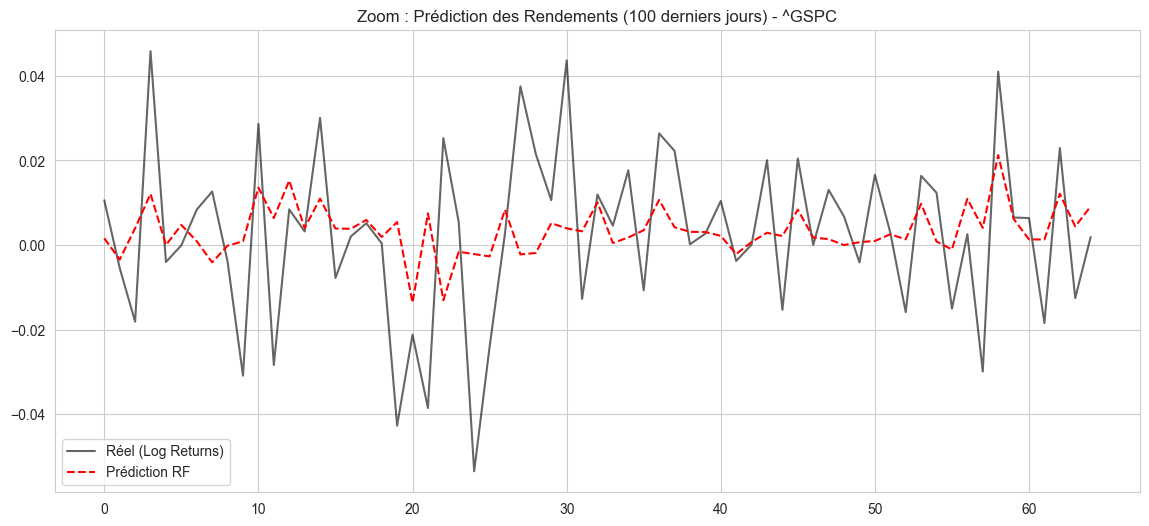

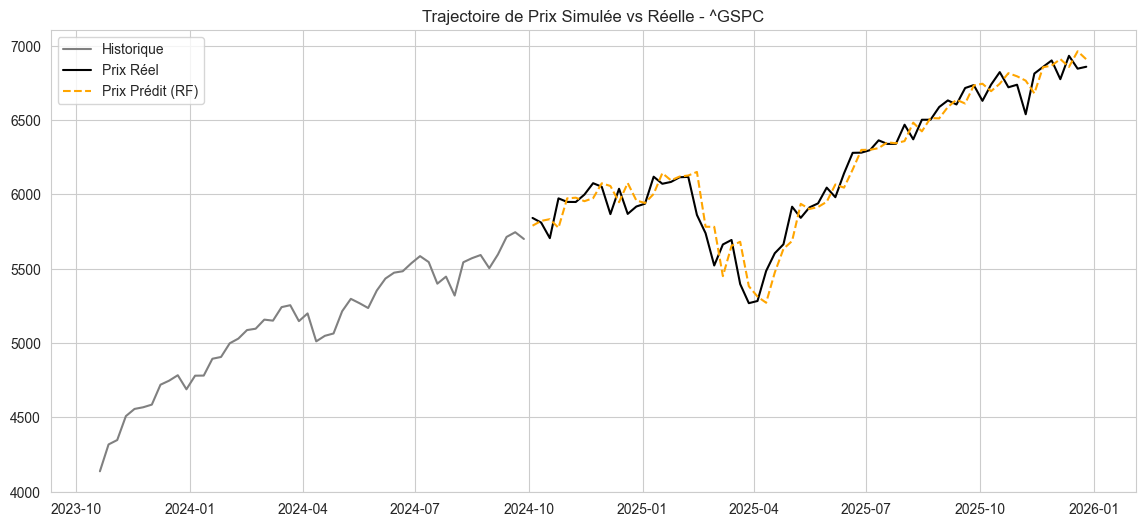

C:\Users\anton\AppData\Local\Temp\ipykernel_15176\1435915851.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')


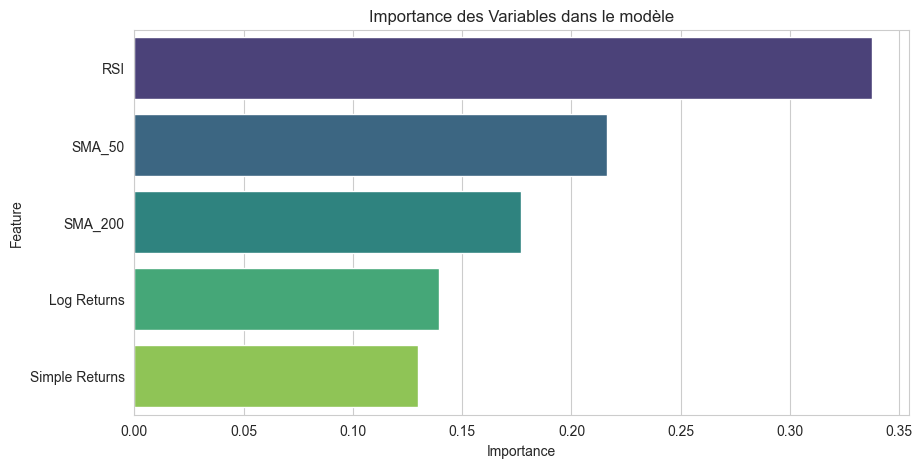

In [ ]:
# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import de vos modules locaux (assurez-vous d'être à la racine du projet ou d'ajuster le path)
from src.data_loader import DataLoader
from src.features import FeatureEngineer
from src.models import ModelPreparator, RegressionModels

# Configuration graphiques
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# ==========================================
# 2. Chargement et Préparation des Données
# ==========================================
ticker = '^GSPC'  # S&P 500 pour le test
print(f"--- Chargement des données pour {ticker} ---")

# A. Chargement
loader = DataLoader(tickers=[ticker], period="10y")
raw_data = loader.load_data()

# B. Ajout des indicateurs (Feature Engineering)
# Le Random Forest a besoin de ces features pour apprendre
fe = FeatureEngineer(raw_data)
fe.add_moving_average(window=50, title='SMA_50')
fe.add_moving_average(window=200, title='SMA_200')
fe.add_rsi(window=14)
df_features = fe.data

# C. Préparation pour le modèle (Log Returns, Target, Split)
# On filtre pour ne garder que l'actif concerné si nécessaire
prep = ModelPreparator(df_features)
df_prepared = prep.prepare_data()

# Split Train (80%) / Test (20%)
train_df, test_df = prep.train_test_split(train_size=0.8)

# Création des matrices X et y normalisées
# get_X_y gère le drop des colonnes non numériques et le scaling
X_train, y_train, X_test, y_test, scaler = prep.get_X_y(train_df, test_df)

print(f"Données d'entraînement : {X_train.shape[0]} points")
print(f"Données de test : {X_test.shape[0]} points")

# ==========================================
# 3. Entraînement du Modèle Random Forest
# ==========================================
print("\n--- Entraînement du Random Forest ---")
models = RegressionModels()

# Vous pouvez ajuster les hyperparamètres ici
models.rf_model.n_estimators = 200
models.rf_model.max_depth = 10
models.rf_model.random_state = 42

# Entraînement
models.train_random_forest(X_train, y_train)

# ==========================================
# 4. Évaluation et Métriques
# ==========================================
print("\n--- Évaluation ---")
metrics = models.evaluate(models.rf_model, X_test, y_test)
predictions = metrics['Predictions']

# --- Métrique Clé : Précision Directionnelle ---
# Est-ce que le modèle prédit le bon sens (Hausse/Baisse) ?
pred_signs = np.sign(predictions)
actual_signs = np.sign(y_test)
directional_accuracy = np.mean(pred_signs == actual_signs)

print(f"RMSE (Erreur)            : {metrics['RMSE']:.5f}")
print(f"MAE (Erreur Absolue)     : {metrics['MAE']:.5f}")
print(f"R² (Qualité du fit)      : {metrics['R2']:.5f}")
print(f"-> Précision Directionnelle : {directional_accuracy:.2%} (Chance = 50%)")

# ==========================================
# 5. Visualisation des Résultats
# ==========================================

# A. Comparaison des Rendements (Zoom sur les 100 derniers points)
plt.figure(figsize=(14, 6))
plt.plot(y_test.values[-100:], label='Réel (Log Returns)', color='black', alpha=0.6)
plt.plot(predictions[-100:], label='Prédiction RF', color='red', linestyle='--')
plt.title(f"Zoom : Prédiction des Rendements (100 derniers jours) - {ticker}")
plt.legend()
plt.show()

# B. Reconstruction des Prix (Simulation d'investissement)
# On reconstruit les prix à partir des log-returns prédits
reconstructed = prep.reconstruct_prices(predictions, test_df.index)

plt.figure(figsize=(14, 6))
# On affiche la fin du train pour la continuité
plt.plot(train_df.index.get_level_values('Date')[-50:], train_df['Close'].iloc[-50:], label='Historique', color='grey')
# Prix Réel Test
plt.plot(reconstructed.index.get_level_values('Date'), reconstructed['Actual_Close_t+1'], label='Prix Réel', color='black')
# Prix Prédit Test
plt.plot(reconstructed.index.get_level_values('Date'), reconstructed['Predicted_Close_t+1'], label='Prix Prédit (RF)', color='orange', linestyle='--')
plt.title(f"Trajectoire de Prix Simulée vs Réelle - {ticker}")
plt.legend()
plt.show()

# C. Importance des Variables
if hasattr(models.rf_model, 'feature_importances_'):
    # Récupération des noms de colonnes
    cols_to_drop = ['Target', 'Open', 'High', 'Low', 'Close', 'Volume', 'Ticker', 'Date']
    feature_names = [c for c in train_df.columns if c not in cols_to_drop]
    # Filtrage pour ne garder que les colonnes numériques (comme fait dans get_X_y)
    numeric_features = train_df[feature_names].select_dtypes(include=[np.number]).columns
    
    importances = pd.DataFrame({
        'Feature': numeric_features,
        'Importance': models.rf_model.feature_importances_
    }).sort_values(by='Importance', ascending=False)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')
    plt.title("Importance des Variables dans le modèle")
    plt.show()

In [9]:
# Dictionnaire de configuration
assets_config = {
    # Indices
    '^GSPC': 'Index', '^IXIC': 'Index', '^FCHI': 'Index', '^DJI': 'Index', 
    '^GDAXI': 'Index', '^N225': 'Index', '^FTSE': 'Index', '^HSI': 'Index',
    'SPY': 'Index', 'QQQ': 'Index', 'IWM': 'Index',
    
    # Commodities
    'GLD': 'Commodities', 'USO': 'Commodities', 'SLV': 'Commodities', 
    'PPLT': 'Commodities', 'UNG': 'Commodities', 'DBA': 'Commodities', 
    'DBC': 'Commodities', 'COPX': 'Commodities', 'CORN': 'Commodities',
    
    # Bonds
    'TLT': 'Bonds', 'IEF': 'Bonds', 'SHY': 'Bonds', 
    'LQD': 'Bonds', 'HYG': 'Bonds', 'BND': 'Bonds', 'TIP': 'Bonds',
    
    # Crypto
    'BTC-USD': 'Crypto', 'ETH-USD': 'Crypto', 'SOL-USD': 'Crypto', 
    'XRP-USD': 'Crypto', 'ADA-USD': 'Crypto', 'LTC-USD': 'Crypto', 
    'DOGE-USD': 'Crypto', 'AVAX-USD': 'Crypto',
    
    # Forex
    'EURUSD=X': 'Forex', 'GBPUSD=X': 'Forex', 'JPY=X': 'Forex', 
    'AUDUSD=X': 'Forex', 'USDCAD=X': 'Forex', 'CHF=X': 'Forex', 'NZDUSD=X': 'Forex'
}

# La liste complète pour le téléchargement
all_tickers = list(assets_config.keys())